## MODELLING

In [17]:
# Import pre-processing libraries
import pandas as pd
import numpy as np
import keras_tuner as kt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout,LSTM
from xgboost import XGBClassifier


from warnings import filterwarnings
filterwarnings('ignore')



In [18]:
# Load the preprocessed data
df = pd.read_csv('Data/Merged_df.csv')
df.head()

,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Sector,30_day_SMA,30_day_EMA,100_day_SMA,100_day_EMA
0,2021-05-27,EGAD,Eaagads Ltd,10.0,15.0,15.0,15.0,15.00,15.00,0.00,0.00,0.0,Agricultural,14.626667,14.531725,13.7015,13.809821
1,2021-05-27,KUKZ,Kakuzi Plc,351.0,415.0,360.0,360.0,360.00,360.00,0.00,0.00,0.0,Agricultural,357.991667,358.862726,362.3375,360.845017
2,2021-05-27,KAPC,Kapchorua Tea Kenya Plc,68.5,101.0,80.0,80.0,80.00,82.25,-2.25,2.74,100.0,Agricultural,82.983333,82.299282,81.6700,81.703717
3,2021-05-27,LIMT,Limuru Tea Plc,260.0,400.0,340.0,340.0,340.00,340.00,0.00,0.00,0.0,Agricultural,348.666667,346.436461,356.6000,354.235245
4,2021-05-27,SASN,Sasini Plc,16.0,20.0,18.2,18.3,18.25,18.35,-0.10,0.54,1600.0,Agricultural,18.228333,18.242686,17.9010,18.179957


In [19]:
# Create a pipeline for pre-processing
def create_preprocessing_pipeline(numerical_features, categorical_features):
    # Define numerical transformations
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    # Define categorical transformations
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine transformations
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    return preprocessor

The pipeline help in fast pre-processing

In [20]:
# Define numerical and categorical columns
numerical_cols = ['Day Price', '12m Low', '12m High', 'Day Low', 'Day High', 'Volume', 'Change', 'Change%']
categorical_cols = ['Code', 'Name', 'Sector']

# call the function to create the preprocessor
preprocessor = create_preprocessing_pipeline(numerical_cols, categorical_cols)
# create binary target variable
df['Target'] = (df['Day Price'] > df['Day Price'].shift(1)).astype(int)
print(df['Target'].value_counts())


Target
1    30986
0    23243
Name: count, dtype: int64


### Split the data for training and testing

In [21]:
# 1. Split the data based on year: train (2021-2022), validation (2023), test (2024)
X = df.drop(columns=['Target'])                # Features: all columns except 'Target'
y = df['Target']                              # Target variable


# create masks for training and testing based on year
train_mask = X['Date'].isin([2021, 2022, 2023])  # Training data: years 2021, 2022, and 2023
test_mask = X['Date'] == 2024                  # Testing data: year 2024

# apply the masks to split the data for training
X_train = X[train_mask]
y_train = y[train_mask]

# apply the mask to split the data for testing
X_test = X[test_mask]
y_test = y[test_mask]

# Drop the 'Year' column from the training and testing sets
X_train = X_train.drop(columns=['Date'])
X_test = X_test.drop(columns=['Date'])


In [22]:
print(df.columns)


Index(['Date', 'Code', 'Name', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Sector',
       '30_day_SMA', '30_day_EMA', '100_day_SMA', '100_day_EMA', 'Target'],
      dtype='object')


In [23]:

#data splitting and preprocessing strategies
# 3. Split the data randomly into training and testing sets (80/20 split)
X = df.drop(columns=['Target'])                # Features: all columns except 'Target'
y = df['Target']                              # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Preprocess the training and test data
X_train_transformed = preprocessor.fit_transform(X_train)  # Fit and transform training data
X_test_transformed = preprocessor.transform(X_test)        # Transform test data

# 5. Feature selection: select top 10 features
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

# 6. Dimensionality reduction using PCA (reduce to 5 components)
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

# 7. Print the shape of the transformed data
print("Transformed training data shape:", X_train_pca.shape)
print("Transformed testing data shape:", X_test_pca.shape)


Transformed training data shape: (43383, 5)
Transformed testing data shape: (10846, 5)


### 1. Base model (Logistic Regression)

In [24]:
# create a function to train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test ):
    # Fit the model
    model.fit(X_train, y_train)
    # Make predictions
    y_pred = model.predict(X_test)
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [25]:
# Create the base model pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=10)),
    ('pca', PCA(n_components=5)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit and evaluate the base model
train_and_evaluate_model(model_pipeline, X_train, y_train, X_test, y_test)

Model Accuracy: 0.6716761939885673
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65      4583
           1       0.75      0.64      0.69      6263

    accuracy                           0.67     10846
   macro avg       0.67      0.68      0.67     10846
weighted avg       0.69      0.67      0.67     10846

Confusion Matrix:
[[3270 1313]
 [2248 4015]]


Plot a confusion matrix 

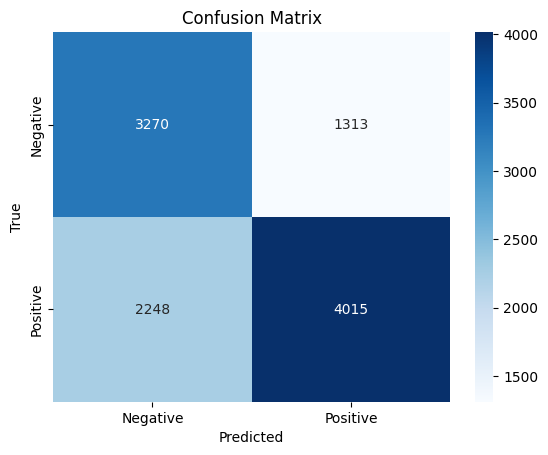

In [26]:
# confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# plot confusion matrix
plot_confusion_matrix(y_test, model_pipeline.predict(X_test))

*Interpretation*
- TN - 3237 > Negative instances correctly predicted as Negative
- FP - 1887 > Negative instances correctly predicted as Positive
- FN - 2351 > Positive instances correctly predicted as Negative
- TP - 4579 > Positive instances correctly predicted as Positive

- An accuracy of 65% suggests that the model correctly predicts the class 65% of the time
- Overall performance is reasonable but the false negatives and false positives show the model could be improved.

#### Hyperparameter tuning

In [27]:
# Tuning hyperparameters for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2', 'l1'],
    'classifier__solver': ['liblinear', 'saga']
}
# Create a GridSearchCV object
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# Fit the grid search to the training data
grid_search.fit(X_train, y_train)
# Get the best model from grid search
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Day Price', '12m Low',
                                                   '12m High', 'Day Low',
                                                   'Day High', 'Volume',
                                                   'Change', 'Change%']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Code', 'Name',
                                                   'Sector'])])),
                ('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x0000017D50B04F40>)),
                ('pca', PCA(n_components=5)),
                ('classifier',
                 LogisticRegression(C=100, max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [28]:
#predict on the test set
y_pred_best = best_model.predict(X_test)
# Evaluate the best model
print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Model Accuracy: 0.6698321962013646


### 2. XG-BOOST model

In [29]:
# create a pipeline for the XGBoost model
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=10)),
    ('pca', PCA(n_components=5)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

In [30]:
#fit and evaluate the XGBoost model
train_and_evaluate_model(xgb_model, X_train, y_train, X_test, y_test)

Model Accuracy: 0.9686520376175548
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      4583
           1       0.96      0.98      0.97      6263

    accuracy                           0.97     10846
   macro avg       0.97      0.97      0.97     10846
weighted avg       0.97      0.97      0.97     10846

Confusion Matrix:
[[4353  230]
 [ 110 6153]]


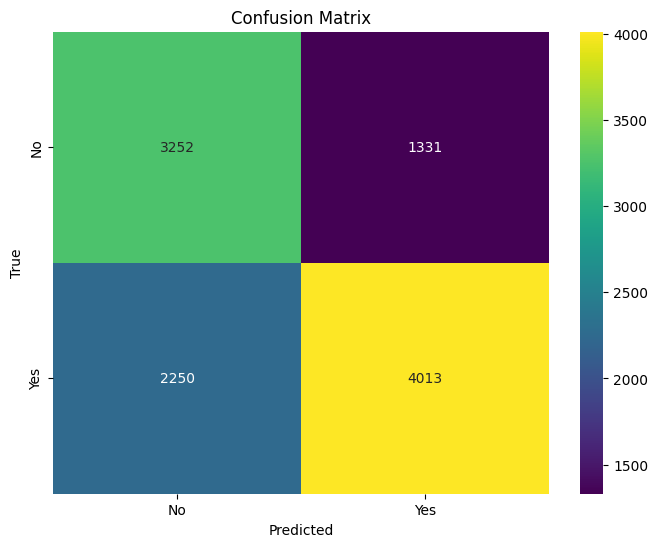

In [31]:
# plot a confusion matrix for the XGBoost model
confusion_matrix_xgb = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_xgb, annot=True, fmt='d', cmap='viridis', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

*Interpretation*
- TN - 3415 > Negative instances correctly predicted as Negative
- FP - 1709 > Negative instances correctly predicted as Positive
- FN - 2379 > Positive instances correctly predicted as Negative
- TP - 4551 > Positive instances correctly predicted as Positive

- An accuracy of 66% suggests that the model correctly predicts the class 65% of the time
- A precision of 73% means the model is right when it predicts yes, its actually yes
- Overall performance is reasonable but the false negatives and false positives show the model could be improved.

In [32]:
# Tune hyperparameters for XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 0.9, 1.0]
}

# Create a GridSearchCV object for XGBoost
xgb_grid_search = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# Fit the grid search to the training data  
xgb_grid_search.fit(X_train, y_train)
# Get the best model from grid search
best_xgb_model = xgb_grid_search.best_estimator_
best_xgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Day Price', '12m Low',
                                                   '12m High', 'Day Low',
                                                   'Day High', 'Volume',
                                                   'Change', 'Change%']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [33]:
# predict on the test set
y_pred_best = best_xgb_model.predict(X_test)
# Evaluate the best XGBoost model
print("Best XGBoost Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best XGBoost Model Accuracy: 0.9744606306472432


In [34]:
# Evaluate the XGBoost model
train_and_evaluate_model(best_xgb_model, X_train, y_train, X_test, y_test)

Model Accuracy: 0.9744606306472432
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      4583
           1       0.97      0.99      0.98      6263

    accuracy                           0.97     10846
   macro avg       0.98      0.97      0.97     10846
weighted avg       0.97      0.97      0.97     10846

Confusion Matrix:
[[4395  188]
 [  89 6174]]


### 3. Long Short-Term Memory > A special type of RNN

In [35]:
# create a LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50,activation='relu', input_shape=(X_train_pca.shape[1], 1)))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
# Compile the LSTM model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Reshape the input data for LSTM
X_train_lstm = X_train_pca.reshape((X_train_pca.shape[0], X_train_pca.shape[1], 1))
X_test_lstm = X_test_pca.reshape((X_test_pca.shape[0], X_test_pca.shape[1], 1))
# Fit the LSTM model
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))
# Evaluate the LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test)
print(f"LSTM Model Accuracy: {lstm_accuracy}")

Epoch 1/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6405 - loss: 0.5979 - val_accuracy: 0.6862 - val_loss: 0.5229
Epoch 2/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6943 - loss: 0.5112 - val_accuracy: 0.6859 - val_loss: 0.5035
Epoch 3/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6971 - loss: 0.4983 - val_accuracy: 0.6956 - val_loss: 0.4952
Epoch 4/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7023 - loss: 0.4929 - val_accuracy: 0.7076 - val_loss: 0.4774
Epoch 5/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7294 - loss: 0.4843 - val_accuracy: 0.7570 - val_loss: 0.5022
Epoch 6/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7255 - loss: 0.4879 - val_accuracy: 0.7576 - val_loss: 0.4706
Epoch 7/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7375 - loss: 0.4805 - val_accuracy: 0.7574 - val_loss: 0.4728
Epoch 8/10
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7486 - loss: 0

In [36]:
# Tune LSTM hyperparameters
# Keras Tuner or manual grid search. Here, we will just demonstrate a simple approach.
lstm_param_grid = {
    'epochs': [5, 10],
    'batch_size': [16, 32],
    'lstm_units': [30, 60]
}

# fit the LSTM model with different hyperparameters
for epochs in lstm_param_grid['epochs']:
    for batch_size in lstm_param_grid['batch_size']:
        for lstm_units in lstm_param_grid['lstm_units']:
            # Create a new LSTM model with the current hyperparameters
            lstm_model = Sequential()
            lstm_model.add(LSTM(lstm_units, activation='relu', input_shape=(X_train_pca.shape[1], 1)))
            lstm_model.add(Dense(32, activation='relu'))
            lstm_model.add(Dropout(0.6))
            lstm_model.add(Dense(16, activation='relu'))
            lstm_model.add(Dropout(0.5))
            lstm_model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
            # Compile the LSTM model
            lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            # Fit the LSTM model
            lstm_model.fit(X_train_lstm, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test_lstm, y_test))
# Evaluate the LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test)
print(f"Tuned LSTM Model Accuracy: {lstm_accuracy}")

Epoch 1/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.6269 - loss: 0.6045 - val_accuracy: 0.6789 - val_loss: 0.5055
Epoch 2/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.6917 - loss: 0.5168 - val_accuracy: 0.6906 - val_loss: 0.5107
Epoch 3/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7058 - loss: 0.5030 - val_accuracy: 0.6833 - val_loss: 0.5053
Epoch 4/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.6978 - loss: 0.5060 - val_accuracy: 0.6791 - val_loss: 0.4999
Epoch 5/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7018 - loss: 0.5024 - val_accuracy: 0.7513 - val_loss: 0.4928
Epoch 1/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.6290 - loss: 0.6015 - val_accuracy: 0.6649 - val_loss: 0.5290
Epoch 2/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.6850 - loss: 0.5399 - val_accuracy: 0.7567 - val_loss: 0.5023
Epoch 3/5
2712/2712 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6894 - loss: 0.5145 - 

*Interpretattion*
- This model has an accuracy of approximately 67.47% 
- There is an improvement trend over epochs in training phase

In [37]:
# Improve the model by adding more layers or changing the architecture
# use keras tuner

# Define a function to build the LSTM model
def build_lstm_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=50, max_value=200, step=50), activation='relu', input_shape=(X_train_pca.shape[1], 1)))
    model.add(Dropout(rate=hp.Float('dropout_rate', 0.1, 0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
# Create a Keras Tuner object
tuner = kt.Hyperband(
    build_lstm_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='lstm_tuning',
    project_name='lstm_hyperparameter_tuning'
)
# Search for the best hyperparameters
tuner.search(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))
# Get the best model
best_lstm_model = tuner.get_best_models(num_models=1)[0]
best_lstm_model.summary()

Reloading Tuner from lstm_tuning\lstm_hyperparameter_tuning\tuner0.json



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200)            │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,801 (632.04 KB)

 Trainable params: 161,801 (632.04 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# evaluate the best LSTM model
lstm_loss, lstm_accuracy = best_lstm_model.evaluate(X_test_lstm, y_test)
print(f"Best Tuned LSTM Model Accuracy: {lstm_accuracy}")

339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7692 - loss: 0.6814
Best Tuned LSTM Model Accuracy: 0.772174060344696


### 4. Stacked Long Short-Term Memory Model

In [39]:
# stacked lstm model
# Define a function to build the stacked LSTM model
def build_stacked_lstm_model(hp):
    lstm_units = hp.Int('lstm_units', min_value=50, max_value=200, step=50)
    model = Sequential()
    model.add(LSTM(lstm_units, activation='relu', input_shape=(X_train_pca.shape[1], 1), return_sequences=True))
    model.add(Dropout(hp.Float('dropout_rate_1', 0.1, 0.5, step=0.1)))
    model.add(LSTM(lstm_units // 2, activation='relu'))
    model.add(Dropout(hp.Float('dropout_rate_2', 0.1, 0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [40]:
# run the stacked LSTM model with Keras Tuner
tuner_stacked = kt.Hyperband(
    build_stacked_lstm_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='stacked_lstm_tuning',
    project_name='stacked_lstm_hyperparameter_tuning'
)

# Search for the best hyperparameters for the stacked LSTM model
tuner_stacked.search(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))
# Get the best stacked LSTM model
best_stacked_lstm_model = tuner_stacked.get_best_models(num_models=1)[0]
best_stacked_lstm_model.summary()

Reloading Tuner from stacked_lstm_tuning\stacked_lstm_hyperparameter_tuning\tuner0.json


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 75)             │        67,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            76 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,076 (621.39 KB)

 Trainable params: 159,076 (621.39 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Evaluate the best stacked LSTM model
stacked_lstm_loss, stacked_lstm_accuracy = best_stacked_lstm_model.evaluate(X_test_lstm, y_test)
print(f"Best Stacked LSTM Model Accuracy: {stacked_lstm_accuracy}")

339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7760 - loss: 0.4494
Best Stacked LSTM Model Accuracy: 0.7794578671455383


In [42]:

save_path_stacked = "best_stacked_lstm_model.keras"


In [43]:
# Convolutional Neural Network (CNN) model
# Define a function to build the CNN model
from keras.layers import Conv1D, MaxPooling1D, Flatten
def build_cnn_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Int('filters', min_value=32, max_value=128, step=32), kernel_size=3, activation='relu', input_shape=(X_train_pca.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(rate=hp.Float('dropout_rate', 0.1, 0.5, step=0.1)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create a Keras Tuner object for CNN
cnn_tuner = kt.Hyperband(
    build_cnn_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='cnn_tuning',
    project_name='cnn_hyperparameter_tuning'
)

Reloading Tuner from cnn_tuning\cnn_hyperparameter_tuning\tuner0.json


In [44]:
# The cnn model
# Search for the best hyperparameters
cnn_tuner.search(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))
# Get the best model
best_cnn_model = cnn_tuner.get_best_models(num_models=1)[0]
best_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# evaluate the CNN model
cnn_loss, cnn_accuracy = best_cnn_model.evaluate(X_test_lstm, y_test)

339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7449 - loss: 0.5118


In [46]:
# print the actual and predicted values
print("Actual values:", y_test.values)
print("Predicted values:", y_pred_best)
print("CNN Model Accuracy:", cnn_accuracy)

Actual values: [1 1 0 ... 0 0 1]
Predicted values: [1 1 0 ... 1 0 1]
CNN Model Accuracy: 0.7473723292350769


In [47]:
# Top ten performing stocks
top_ten_stocks = df.groupby('Name')['Target'].mean().nlargest(10).index.tolist()
print("Top Ten Performing Stocks:", top_ten_stocks)

Top Ten Performing Stocks: ['ABSA NewGold ETF', 'BK Group Plc', 'BOC Kenya Plc', 'Bamburi Cement Ltd', 'British American Tobacco Kenya Plc', 'Diamond Trust Bank Kenya Ltd', 'East African Breweries Ltd', 'Eveready East Africa Ltd', 'Express Kenya Plc', 'I & M Holdings Plc']


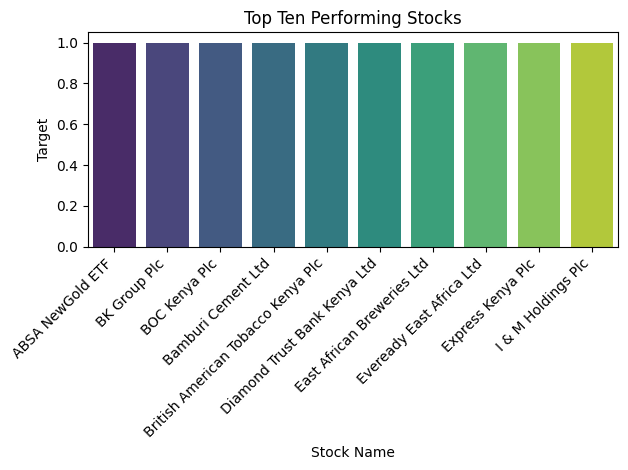

In [48]:
# Visualize the top ten performing stocks
top_ten_df = df[df['Name'].isin(top_ten_stocks)][['Name', 'Target']].groupby('Name').mean().reset_index()
top_ten_df.columns = ['Name', 'Target']
top_ten_df_sorted = top_ten_df.sort_values(by='Target', ascending=False)
sns.barplot(data=top_ten_df_sorted, x='Name', y='Target', palette='viridis')
plt.title('Top Ten Performing Stocks')
plt.xlabel('Stock Name')
plt.ylabel('Target')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#

In [49]:
# save the best stacked lstm as keras format
save_path_stacked = "best_stacked_lstm_model.keras"
# Save the best stacked LSTM model in Keras format
best_stacked_lstm_model.save(save_path_stacked)

## Model Deployment

The trained stacked lstm model is deployed using a simple Streamlit web application. This allows users to interactively input their user market sector preferences and receive personalized stocks recommendations in real time.

**Deployment Steps:**
1. The best-performing lstm model is saved as a keras after training.
2. A Streamlit app loads the saved model and provides a user-friendly interface for input.
3. Users enter their market sector, amount to invest, risk tolerance and length of investment.
4. The app predicts and displays the top 5 recommended stocks based on the user's inputs.

This deployment approach makes the recommendation system accessible to end-users and demonstrates how machine learning models can be integrated into interactive web applications for practical use.

View github for more, link [here](https://github.com/Sylvia-W-Mwangi/NSE_TIME_SERIES_ANALYSIS)